# Regressão com Regularização L1 + L2 (Elastic Net)

Nesse notebook iremos treinar um modelo de regressão com regularização L1 e L2, também conhecido como Elastic Net e iremos comparar seus resultados com o baseline e o Ridge.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [2]:
df = pd.read_parquet("../../data/processed/03_processed.parquet")

In [3]:
df = df.convert_dtypes()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   tipo_imovel                       7919 non-null   string  
 1   preco                             7919 non-null   Int64   
 2   condominio                        4602 non-null   Int64   
 3   area_m2                           7919 non-null   Int64   
 4   quartos                           7918 non-null   Int64   
 5   banheiros                         7918 non-null   Int64   
 6   vagas                             7286 non-null   Int64   
 7   piscina                           7919 non-null   boolean 
 8   espaco_gourmet                    7919 non-null   boolean 
 9   academia                          7919 non-null   boolean 
 10  spa_massagem                      7919 non-null   boolean 
 11  espaco_lazer                      7919 non-null   boolean 
 12  are

In [5]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,distancia_aeroporto_km,faixa_area,faixa_condominio,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,16.213545,pequeno,medio,30.0,30.0,0.033333,0.033333,1.0,2.0,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,7.250204,pequeno,NaN,37.0,37.0,0.027027,0.027027,1.0,1.0,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,8.381749,medio,alto,25.0,41.666667,0.04,0.024,1.666667,1.5,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,8.824588,grande,alto,61.0,81.333333,0.016393,0.012295,1.333333,0.75,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,9.267687,pequeno,medio,28.5,28.5,0.035088,0.035088,1.0,2.0,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,4.911235,pequeno,NaN,27.5,27.5,0.036364,0.036364,1.0,2.0,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,9.094186,pequeno,baixo,52.0,52.0,0.019231,0.019231,1.0,<NA>,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,6.613218,medio,NaN,42.666667,42.666667,0.023438,0.023438,1.0,1.5,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,7.747091,medio,alto,26.25,35.0,0.038095,0.028571,1.333333,1.5,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,3.412207,pequeno,baixo,27.5,27.5,0.036364,0.036364,1.0,2.0,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [6]:
from sklearn.model_selection import train_test_split
from utils import random_state

X = df.drop("preco", axis="columns")
y = df["preco"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=random_state,
)

/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelagem

O primeiro modelo que iremos treinar será o nosso baseline, uma regressão linear múltipla. Vamos inicialmente separar as features do nosso dataset baseado nos tipos delas.

In [7]:
discrete_columns = ["quartos", "banheiros", "vagas"]

continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["Int64", "Float64"])
    .columns
    .to_list()
)

ordinal_columns = (X_train
    .select_dtypes(include=["category"])
    .columns
    .to_list()
)

categorical_columns = (X_train
    .select_dtypes(include="string")
    .columns
    .to_list()
)

boolean_columns = (X_train
    .select_dtypes(include="boolean")
    .columns
    .to_list()
)

Agora, vamos montar o nosso pipeline de treinamento para a regressão linear.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.pipeline import Pipeline

from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer

def get_elastic_net_pipeline(parameters):
    imputer = SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clipper", Winsorizer(
            capping_method="quantiles",
            fold=parameters["discrete_fold"],
        )),
        ("scaler", StandardScaler())
    ])

    continuous_pipeline = Pipeline(steps=[
        ("imputer", imputer),
        ("clipper", Winsorizer(
            capping_method="quantiles",
            fold=parameters["continuous_fold"],
        )),
        ("normalizer", YeoJohnsonTransformer(
            variables=["condominio", "area_m2"]
        )),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])


    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            ("discrete", discrete_pipeline, discrete_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
            ("boolean", boolean_pipeline, boolean_columns),
        ],
        remainder="drop",
    )

    regressor = ElasticNet(
        alpha=parameters["alpha"],
        l1_ratio=parameters["l1_ratio"],
        max_iter=5000,
        random_state=random_state,
    )

    transformer = QuantileTransformer(
        output_distribution="normal",
        random_state=random_state,
    )

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline

def get_elastic_net_parameters(trial):
    return {
        "alpha": trial.suggest_float("alpha", 1e-3, 1e3, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 0.99),
        "continuous_fold": trial.suggest_float("continuous_fold", 1e-3, 1e-2, log=True),
        "discrete_fold": trial.suggest_float("discrete_fold", 1e-3, 1e-2, log=True),
    }

In [9]:
import utils

study = utils.get_study(
    get_pipeline=get_elastic_net_pipeline,
    get_parameters=get_elastic_net_parameters,
    X_train=X_train,
    y_train=y_train,
    n_trials=100
)

[I 2026-08-23 16:11:06,717] A new study created in memory with name: no-name-80273d11-ed91-465a-85e6-de8216f0a987
Best trial: 0. Best value: -1.56843e+06:   1%|          | 1/100 [00:01<01:45,  1.07s/it]

[I 2026-08-23 16:11:07,792] Trial 0 finished with value: -1568434.1074172354 and parameters: {'alpha': 233.53148753974796, 'l1_ratio': 0.09943259994117443, 'continuous_fold': 0.0023241627565418546, 'discrete_fold': 0.0010054464364877714}. Best is trial 0 with value: -1568434.1074172354.


Best trial: 1. Best value: -1.38643e+06:   2%|▏         | 2/100 [00:02<01:42,  1.04s/it]

[I 2026-08-23 16:11:08,808] Trial 1 finished with value: -1386433.603833133 and parameters: {'alpha': 0.49565452725985515, 'l1_ratio': 0.7225977098910595, 'continuous_fold': 0.001077303418982776, 'discrete_fold': 0.0014899699666651627}. Best is trial 1 with value: -1386433.603833133.


Best trial: 2. Best value: -926293:   3%|▎         | 3/100 [00:03<01:55,  1.20s/it]     

...

[I 2026-08-23 16:13:37,081] Trial 97 finished with value: -928775.5901923592 and parameters: {'alpha': 0.003924755375557674, 'l1_ratio': 0.3374504565182094, 'continuous_fold': 0.006161037486447728, 'discrete_fold': 0.001280171288403739}. Best is trial 71 with value: -913446.238279281.


Best trial: 71. Best value: -913446:  99%|█████████▉| 99/100 [02:32<00:01,  1.69s/it]

[I 2026-08-23 16:13:38,953] Trial 98 finished with value: -915864.8786497557 and parameters: {'alpha': 0.001453964043020313, 'l1_ratio': 0.2363414372136457, 'continuous_fold': 0.0019226260284853284, 'discrete_fold': 0.0014923523633754486}. Best is trial 71 with value: -913446.238279281.


Best trial: 71. Best value: -913446: 100%|██████████| 100/100 [02:33<00:00,  1.54s/it]

[I 2026-08-23 16:13:40,234] Trial 99 finished with value: -921465.2840000317 and parameters: {'alpha': 0.002556538750299919, 'l1_ratio': 0.3693903193876769, 'continuous_fold': 0.0022431834670837048, 'discrete_fold': 0.00225037697148366}. Best is trial 71 with value: -913446.238279281.


Vamos olhar as métricas do nosso modelo nos dados de treinamento.

In [11]:
utils.report_scores(
    get_pipeline=get_elastic_net_pipeline,
    study=study,
    X=X_train,
    y=y_train
)

R2: 0.62
RMSE: R$ 913446.24
MAE: R$ 365077.84
MedAE: R$ 126585.22
MAPE: 0.26%


E nos dados de teste.

In [12]:
utils.report_scores(
    get_pipeline=get_elastic_net_pipeline,
    study=study,
    X=X_test,
    y=y_test
)

R2: 0.60
RMSE: R$ 924511.85
MAE: R$ 386347.69
MedAE: R$ 135153.73
MAPE: 0.28%


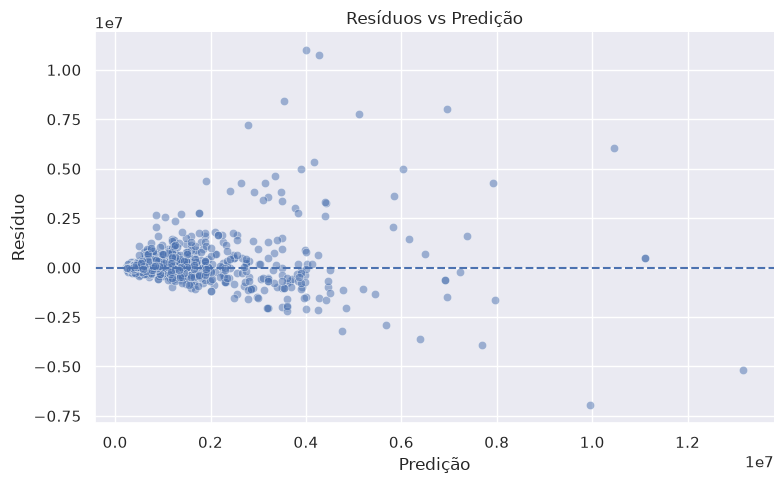

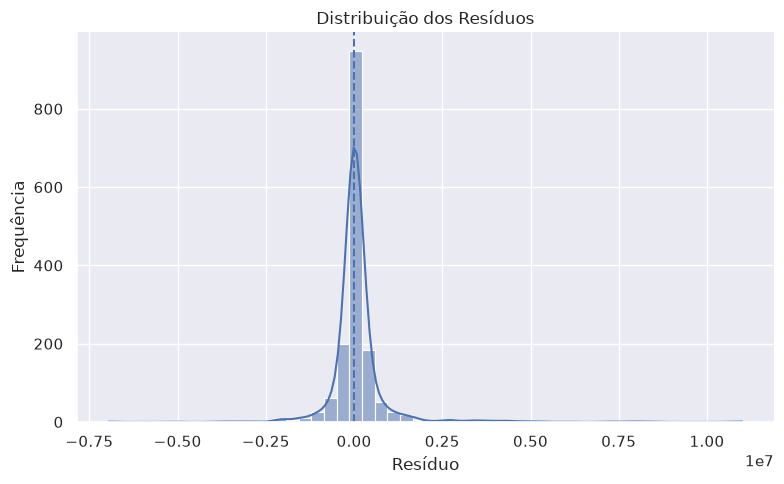

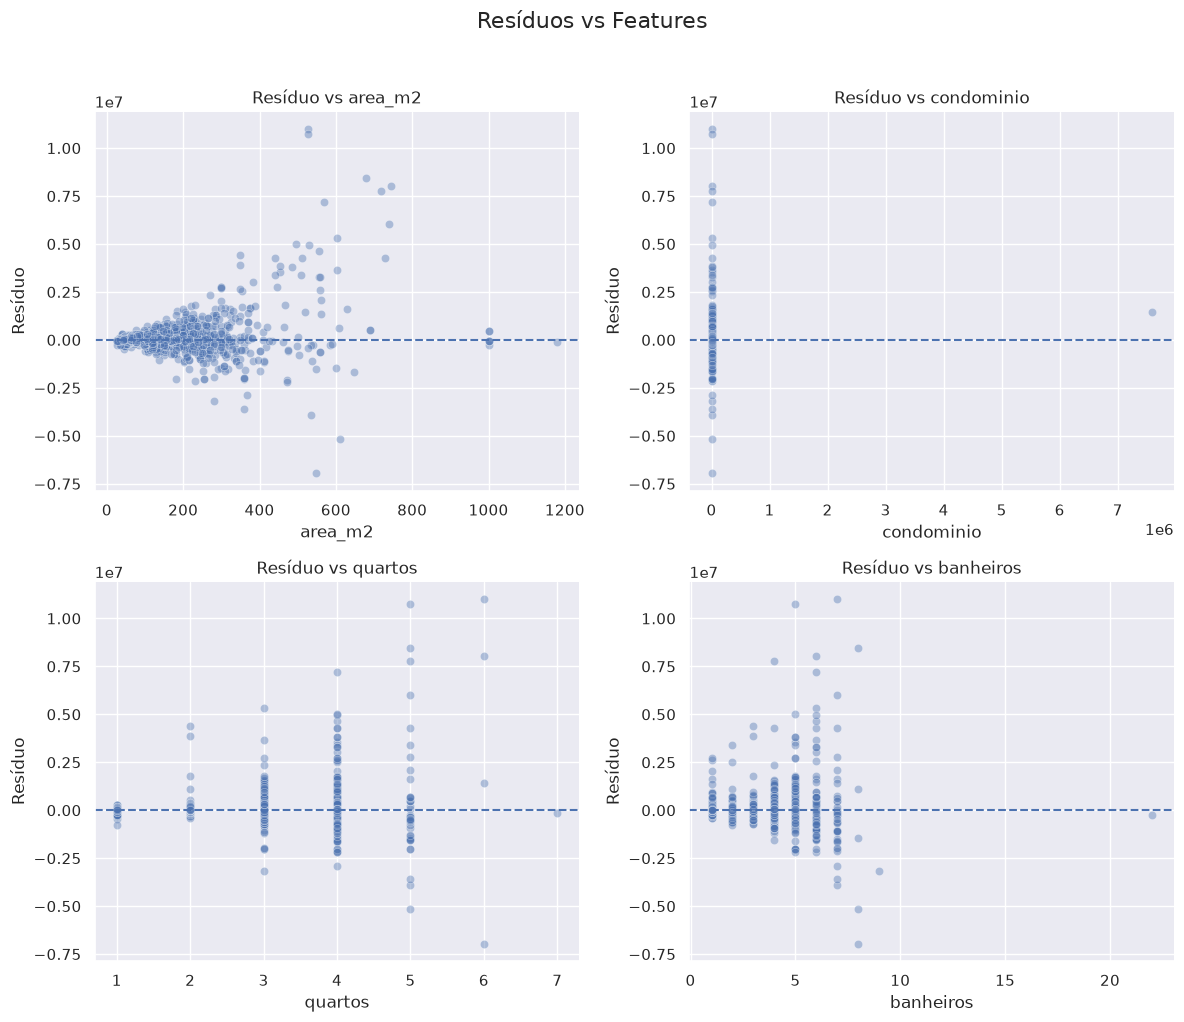

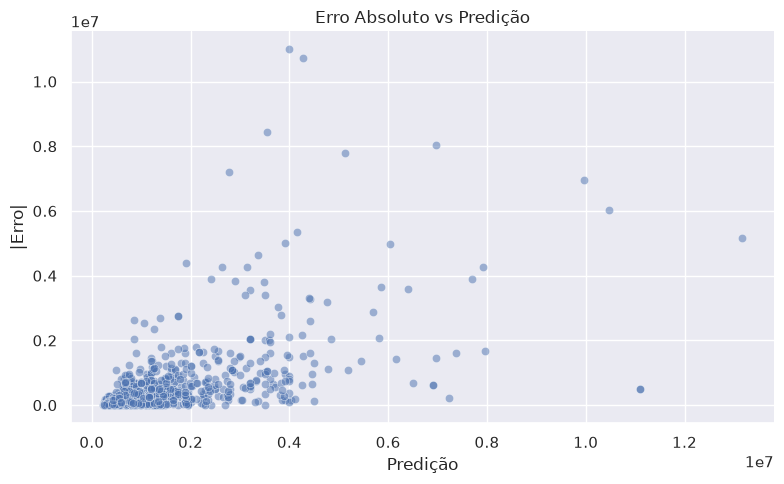


=== Erro Relativo Absoluto ===
count      1584.0
mean     0.268269
std      0.345996
min           0.0
25%      0.090859
50%      0.184877
75%      0.330945
max       5.00757
Name: absolute_relative_error, dtype: Float64

=== 20 Maiores Erros Absolutos ===
     tipo_imovel  condominio  area_m2  quartos  banheiros  vagas  piscina  espaco_gourmet  academia  spa_massagem  espaco_lazer  area_trabalho  espaco_infantil  area_esportiva  portaria  seguranca  servicos_garagem  acessibilidade   pets  varanda  area_verde  espaco_natural  acabamento_premium  moveis_embutidos  layout_premium  cozinha  servicos  conforto_interno  mobiliado  casa_inteligente  servicos_conectividade  infra_energetica  infra_hidrica  servicos_sustentaveis   latitude  longitude  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_setor_central_km  distancia_setor_bueno_km  distancia_setor_marista_km  distancia_jardim_goias_km  distancia_aeroporto_km    faixa_area f

In [13]:
linear_regression_error_df = utils.get_residual_analysis(
    get_pipeline=get_elastic_net_pipeline,
    study=study,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)